In [228]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import shap

In [229]:
data = fetch_california_housing(as_frame= True)

df = data.frame.copy()

In [230]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [231]:
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])


In [232]:
pipeline_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [233]:
y_pred_ridge = pipeline_ridge.predict(X_test)

ridge_test_base_r2 = r2_score(y_test, y_pred_ridge)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

R2 Score: 0.5758157428913684
MSE: 0.555854858943597


In [234]:
cv_ridge = KFold(n_splits= 5, shuffle= True, random_state= 42)

ridge_cv_base_scores = cross_val_score(
    pipeline_ridge,
    X,
    y,
    cv=cv_ridge,
    scoring="r2"
)

print("Ridge R2:", ridge_cv_base_scores)
print("Mean Ridge R2:", ridge_cv_base_scores.mean())
print("Std Ridge R2:", ridge_cv_base_scores.std())

Ridge R2: [0.57581574 0.61374535 0.60854953 0.62126497 0.58752907]
Mean Ridge R2: 0.6013809326409961
Std Ridge R2: 0.017000561775507055


In [235]:
param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [236]:
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=cv_ridge,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [237]:
grid_ridge.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how t

In [238]:
best_ridge_model = grid_ridge.best_estimator_

In [239]:
y_pred_ridge_best = best_ridge_model.predict(X_test)

ridge_test_best_r2 = r2_score(y_test, y_pred_ridge_best)

In [240]:
print("Best Ridge Params Gride:", grid_ridge.best_params_)
print("Best Ridge CV R2:", grid_ridge.best_score_)

print("Test Ridge R2:", r2_score(y_test, y_pred_ridge_best))
print("Test Ridge MSE:", mean_squared_error(y_test, y_pred_ridge_best))

Best Ridge Params Gride: {'model__alpha': 1}
Best Ridge CV R2: 0.6114572782460861
Test Ridge R2: 0.5758157428913684
Test Ridge MSE: 0.555854858943597


In [241]:
ridge_best_cv_mean = grid_ridge.best_score_

best_index = grid_ridge.best_index_
ridge_best_cv_std = grid_ridge.cv_results_["std_test_score"][best_index]

In [242]:
ridge_model = best_ridge_model.named_steps["model"]

In [243]:
explainer_ridge = shap.LinearExplainer(ridge_model, X_train)

Background dataset has 16512 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=16512 when initializing the masker.


In [244]:
X_sample = X_test.sample(500, random_state=42)

In [245]:
shap_values_ridge = explainer_ridge.shap_values(X_sample)

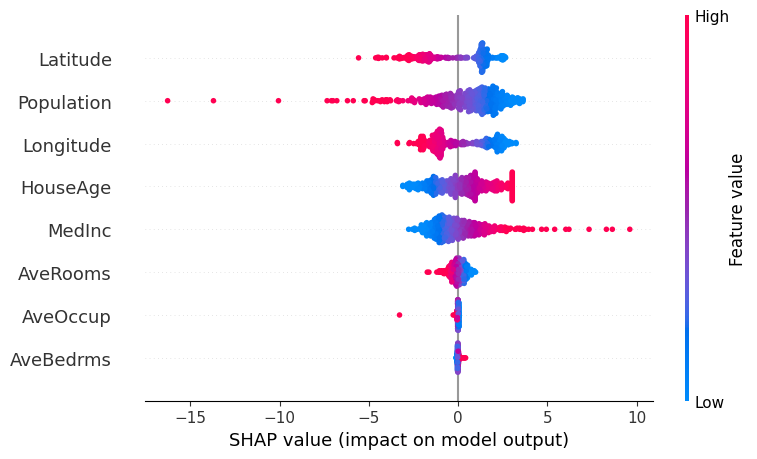

In [246]:
shap.summary_plot(shap_values_ridge, X_sample)

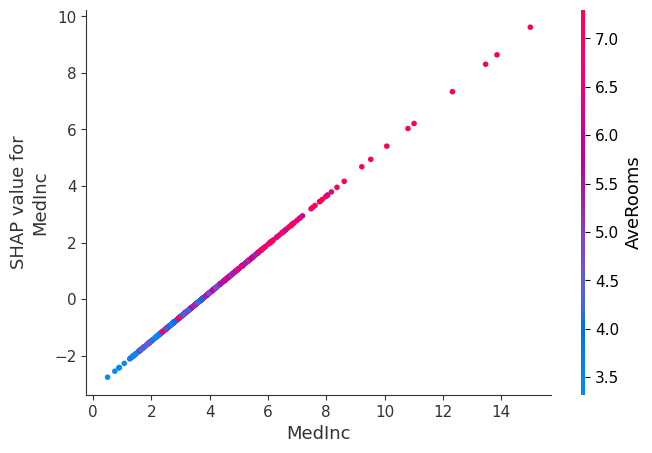

In [247]:
shap.dependence_plot("MedInc", shap_values_ridge, X_sample)

In [248]:
shap_df_ridge = pd.DataFrame({
    "feature": X.columns,
    "shap_mean": np.abs(shap_values_ridge).mean(axis=0)
}).sort_values(by="shap_mean", ascending=False)

print(shap_df_ridge)

      feature  shap_mean
6    Latitude   1.730525
4  Population   1.699493
7   Longitude   1.545216
1    HouseAge   1.241916
0      MedInc   1.148147
2    AveRooms   0.305459
5    AveOccup   0.030109
3   AveBedrms   0.026491


In [249]:
pipeline_forest = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [250]:
pipeline_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_

In [251]:
y_pred_forest = pipeline_forest.predict(X_test)

rf_test_base_r2 = r2_score(y_test, y_pred_forest)

print("R2 Score:", r2_score(y_test, y_pred_forest))
print("MSE:", mean_squared_error(y_test, y_pred_forest))

R2 Score: 0.8046244867176197
MSE: 0.25602182673365537


In [252]:
cv_forest = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_base_scores = cross_val_score(
    pipeline_forest,
    X,
    y,
    cv=cv_forest,
    scoring="r2"
)


print("Forest R2:", rf_cv_base_scores)
print("Mean Forest R2:", rf_cv_base_scores.mean())
print("Std Forest R2:", rf_cv_base_scores.std())

Forest R2: [0.80510827 0.8111991  0.80494776 0.82156539 0.80479553]
Mean Forest R2: 0.8095232105599919
Std Forest R2: 0.006489994860389446


In [253]:
param_grid_forest = {
    "model__n_estimators": [1000],
    "model__max_depth": [None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["log2"]
}

In [254]:
grid_forest = GridSearchCV(
    estimator=pipeline_forest,
    param_grid=param_grid_forest,
    cv=cv_forest,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [255]:
grid_forest.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None], 'model__max_features': ['log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metr

In [256]:
best_forest_model = grid_forest.best_estimator_

In [257]:
y_pred_forest_best = best_forest_model.predict(X_test)

rf_test_best_r2 = r2_score(y_test, y_pred_forest_best)

In [258]:
print("Best Forest Params Gride:", grid_forest.best_params_)
print("Best Forset CV R2:", grid_forest.best_score_)

print("Test Forest R2:", r2_score(y_test, y_pred_forest_best))
print("Test Forest MSE:", mean_squared_error(y_test, y_pred_forest_best))


Best Forest Params Gride: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 1000}
Best Forset CV R2: 0.8187570606694801
Test Forest R2: 0.818179593204102
Test Forest MSE: 0.2382590934927573


In [259]:
rf_best_cv_mean = grid_forest.best_score_

best_index_rf = grid_forest.best_index_
rf_best_cv_std = grid_forest.cv_results_["std_test_score"][best_index_rf]


In [260]:
forest_model = best_forest_model.named_steps["model"]

In [261]:
explainer_forest = shap.TreeExplainer(forest_model)

In [262]:
shap_values_forest = explainer_forest.shap_values(X_sample)

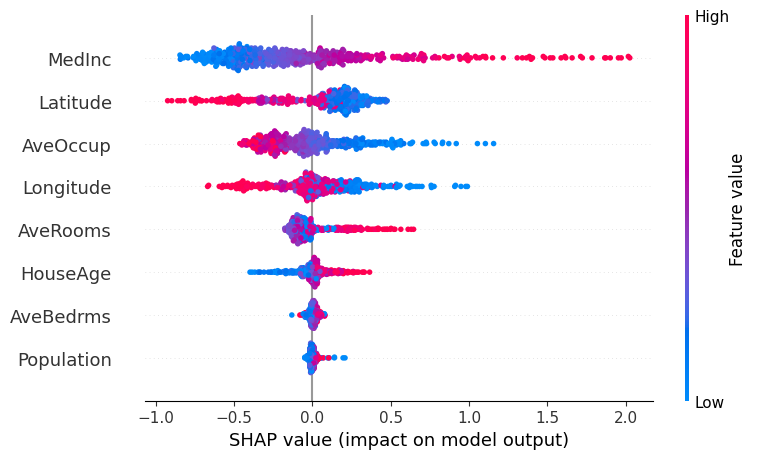

In [263]:
shap.summary_plot(shap_values_forest, X_sample)

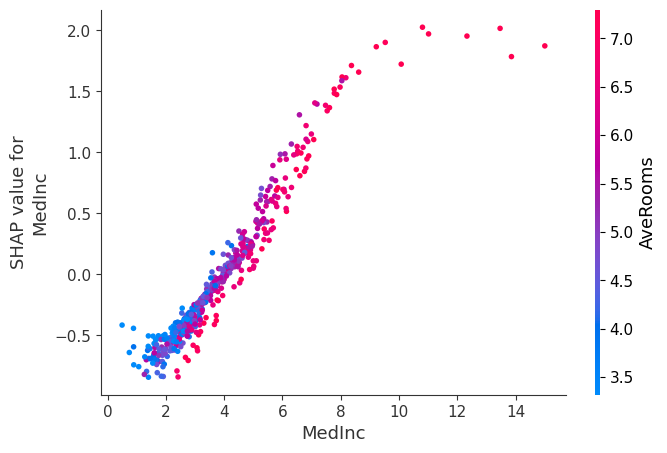

In [264]:
shap.dependence_plot("MedInc", shap_values_forest, X_sample)

In [265]:
shap_df_forest = pd.DataFrame({
    "feature": X.columns,
    "shap_mean": np.abs(shap_values_forest).mean(axis=0)
}).sort_values(by="shap_mean", ascending=False)

print(shap_df_forest)

      feature  shap_mean
0      MedInc   0.443748
6    Latitude   0.254941
5    AveOccup   0.221650
7   Longitude   0.202810
2    AveRooms   0.116240
1    HouseAge   0.068210
3   AveBedrms   0.019921
4  Population   0.014992


In [266]:
pipeline_gb = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])

In [267]:
pipeline_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100


In [268]:
y_pred_gb = pipeline_gb.predict(X_test)

gb_test_base_r2 = r2_score(y_test, y_pred_gb)

print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))

R2 Score: 0.7756446042829697
MSE: 0.2939973248643864


In [269]:
cv_gb = KFold(n_splits=5, shuffle=True, random_state=42)

gb_cv_base_scores = cross_val_score(
    pipeline_gb,
    X,
    y,
    cv=cv_gb,
    scoring="r2"
)


print("GB R2:", gb_cv_base_scores)
print("Mean GB R2:", gb_cv_base_scores.mean())
print("Std GB R2:", gb_cv_base_scores.std())

GB R2: [0.7756446  0.79377022 0.78883536 0.80436156 0.77583447]
Mean GB R2: 0.7876892432186777
Std GB R2: 0.010971480636951032


In [270]:
param_grid_gb = {
    "model__n_estimators": [500, 1000],
    "model__learning_rate": [0.1, 0.2],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}

In [271]:
grid_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid_gb,
    cv=cv_gb,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [272]:
grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.1, 0.2], 'model__max_depth': [3, 5], 'model__n_estimators': [500, 1000], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceva

In [273]:
best_gb_model = grid_gb.best_estimator_

In [274]:
y_pred_gb_best = best_gb_model.predict(X_test)

gb_test_best_r2 = r2_score(y_test, y_pred_gb_best)

In [275]:
print("Best GB Params Gride:", grid_gb.best_params_)
print("Best GB CV R2:", grid_gb.best_score_)

print("Test GB R2:", r2_score(y_test, y_pred_gb_best))
print("Test GB MSE:", mean_squared_error(y_test, y_pred_gb_best))

Best GB Params Gride: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 1000, 'model__subsample': 0.8}
Best GB CV R2: 0.8422739395618282
Test GB R2: 0.847994889642696
Test GB MSE: 0.19918886135070996


In [276]:
gb_best_cv_mean = grid_gb.best_score_

best_index_gb = grid_gb.best_index_
gb_best_cv_std = grid_gb.cv_results_["std_test_score"][best_index_gb]

In [277]:
gb_model = best_gb_model.named_steps["model"]

In [278]:
explainer_gb = shap.TreeExplainer(gb_model)

In [279]:
shap_values_gb = explainer_gb.shap_values(X_sample)

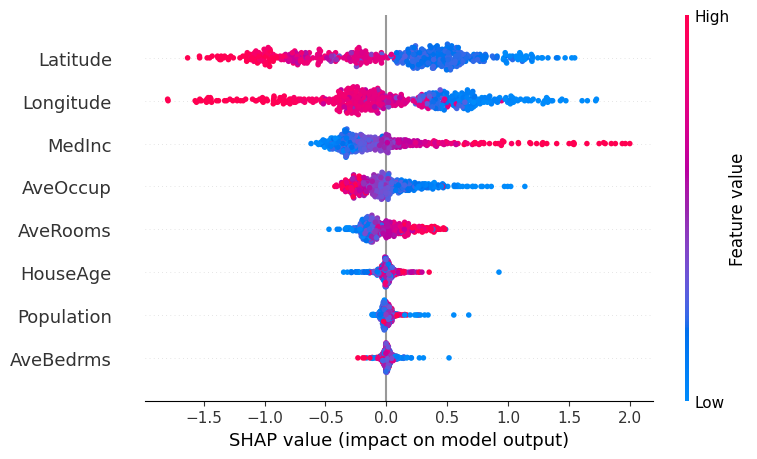

In [280]:
shap.summary_plot(shap_values_gb, X_sample)

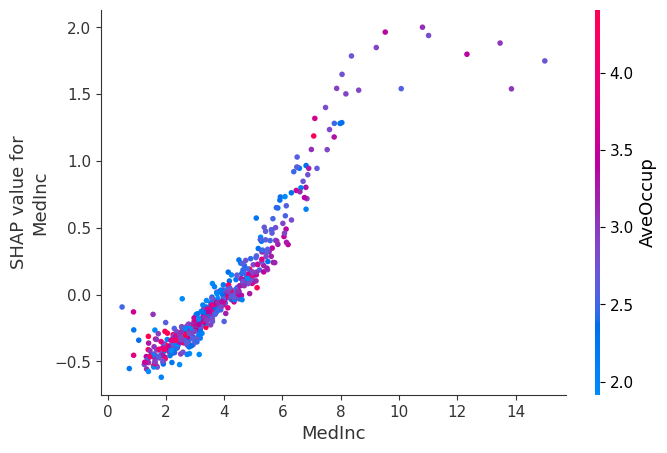

In [281]:
shap.dependence_plot("MedInc", shap_values_gb, X_sample)

In [282]:
shap_df_gb = pd.DataFrame({
    "feature": X.columns,
    "shap_mean": np.abs(shap_values_gb).mean(axis=0)
}).sort_values(by="shap_mean", ascending=False)

print(shap_df_gb)

      feature  shap_mean
6    Latitude   0.588814
7   Longitude   0.525384
0      MedInc   0.333171
5    AveOccup   0.187621
2    AveRooms   0.143524
1    HouseAge   0.047537
4  Population   0.034501
3   AveBedrms   0.031688


In [ ]:
results_final = pd.DataFrame({
    "Model": [
        "Ridge (Base)",
        "Ridge (Best)",
        "Random Forest (Base)",
        "Random Forest (Best)",
        "Gradient Boosting (Base)",
        "Gradient Boosting (Best)"
    ],
    "CV_R2": [
        ridge_cv_base_scores.mean(),
        grid_ridge.best_score_,
        rf_cv_base_scores.mean(),
        grid_forest.best_score_,
        gb_cv_base_scores.mean(),
        grid_gb.best_score_
    ],
    "Test_R2": [
        ridge_test_base_r2,
        ridge_test_best_r2,
        rf_test_base_r2,
        rf_test_best_r2,
        gb_test_base_r2,
        gb_test_best_r2
    ]
}).sort_values(by="Test_R2", ascending=False)
results_final

,Model,CV_R2,Test_R2
5,Gradient Boosting (Best),0.842274,0.847995
3,Random Forest (Best),0.818757,0.818180
2,Random Forest (Base),0.809523,0.804624
4,Gradient Boosting (Base),0.787689,0.775645
1,Ridge (Best),0.611457,0.575816
0,Ridge (Base),0.601381,0.575816


In [284]:
shap_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": np.abs(shap_values_ridge).mean(axis=0),
    "RandomForest": np.abs(shap_values_forest).mean(axis=0),
    "GradientBoosting": np.abs(shap_values_gb).mean(axis=0)
}).sort_values(by="GradientBoosting", ascending=False)

shap_comparison

,Feature,Ridge,RandomForest,GradientBoosting
6,Latitude,1.730525,0.254941,0.588814
7,Longitude,1.545216,0.202810,0.525384
0,MedInc,1.148147,0.443748,0.333171
5,AveOccup,0.030109,0.221650,0.187621
2,AveRooms,0.305459,0.116240,0.143524
1,HouseAge,1.241916,0.068210,0.047537
4,Population,1.699493,0.014992,0.034501
3,AveBedrms,0.026491,0.019921,0.031688


In [285]:
shap_comparison_norm = shap_comparison.copy()

for col in ["Ridge", "RandomForest", "GradientBoosting"]:
    shap_comparison_norm[col] = shap_comparison_norm[col] / shap_comparison_norm[col].sum()

shap_comparison_norm

,Feature,Ridge,RandomForest,GradientBoosting
6,Latitude,0.223948,0.189899,0.311173
7,Longitude,0.199967,0.151068,0.277652
0,MedInc,0.148582,0.330535,0.176072
5,AveOccup,0.003896,0.165101,0.099153
2,AveRooms,0.039530,0.086584,0.075849
1,HouseAge,0.160717,0.050808,0.025122
4,Population,0.219932,0.011167,0.018233
3,AveBedrms,0.003428,0.014839,0.016746


In [286]:
shap_comparison["Avg_Importance"] = shap_comparison[
    ["Ridge", "RandomForest", "GradientBoosting"]
].mean(axis=1)

shap_comparison.sort_values("Avg_Importance", ascending=False)

,Feature,Ridge,RandomForest,GradientBoosting,Avg_Importance
6,Latitude,1.730525,0.254941,0.588814,0.858093
7,Longitude,1.545216,0.202810,0.525384,0.757804
0,MedInc,1.148147,0.443748,0.333171,0.641689
4,Population,1.699493,0.014992,0.034501,0.582995
1,HouseAge,1.241916,0.068210,0.047537,0.452554
2,AveRooms,0.305459,0.116240,0.143524,0.188408
5,AveOccup,0.030109,0.221650,0.187621,0.146460
3,AveBedrms,0.026491,0.019921,0.031688,0.026033
